# Traffic Sign Image Classification
### 6CS012 — Final Portfolio Assessment | Part II: Vision Tasks
**Herald College Kathmandu | University of Wolverhampton**

---

This notebook covers the complete end-to-end deep learning pipeline for Traffic Sign Classification:
- **Part A:** CNN from Scratch (Baseline + Deeper Model)
- **Part B:** Transfer Learning (Pre-trained Model Fine-Tuning)

---
## ⚙️ STEP 0 — Google Colab Setup


In [1]:
# ============================================================
# STEP 0 — Colab Setup: Mount Drive & Extract Dataset
# ============================================================

import os
import zipfile
from google.colab import drive, files

# --- Mount Google Drive ---
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Traffic_Sign-20260416T071109Z-3-001.zip'

EXTRACT_DIR = '/content/Traffic_Sign'

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print('Done! Dataset extracted.')
else:
    print('Dataset already extracted. Ready to go!')

TRAIN_DIR = '/content/Traffic_Sign/Train'
TEST_DIR  = '/content/Traffic_Sign/Test'

print(f'\nTrain folder: {TRAIN_DIR}')
print(f'Test folder:  {TEST_DIR}')
print(f'Classes found: {os.listdir(TRAIN_DIR)}')

Mounted at /content/drive
Extracting dataset...
Done! Dataset extracted.

Train folder: /content/Traffic_Sign/Train
Test folder:  /content/Traffic_Sign/Test
Classes found: ['Instructions', 'OverSpeed', 'No Passing', 'Caution']


---
## 📦 STEP 1 — Import Libraries
We import everything we need for the entire notebook up front.

In [2]:
# ============================================================
# STEP 1 — Import All Required Libraries
# ============================================================

# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn (for metrics and train/val split)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow / Keras (deep learning framework)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# Print versions to confirm everything loaded
print('NumPy version    :', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version    :', keras.__version__)

# Check if GPU is available (important for training speed on Colab)
print('\nGPU Available:', tf.config.list_physical_devices('GPU'))

NumPy version    : 2.0.2
TensorFlow version: 2.20.0
Keras version    : 3.13.2

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 🔍 STEP 2 — Dataset Understanding & Analysis



In [3]:
# ============================================================
# STEP 2A — Count Images Per Class
# ============================================================

# Get all class folder names (these are our labels)
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes: {NUM_CLASSES}')
print(f'Class names: {CLASS_NAMES}\n')

# Count images in each class
class_counts = {}
total_images = 0

for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, cls)
    count = len([
        f for f in os.listdir(class_path)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ])
    class_counts[cls] = count
    total_images += count
    print(f'  {cls:20s}: {count} images')

print(f'\nTotal training images: {total_images}')

# Count test images
test_images = len([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(('.png', '.jpg', '.jpeg'))
])
print(f'Total test images    : {test_images}')

Number of classes: 4
Class names: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

  Caution             : 2429 images
  Instructions        : 2848 images
  No Passing          : 5369 images
  OverSpeed           : 5249 images

Total training images: 15895
Total test images    : 4


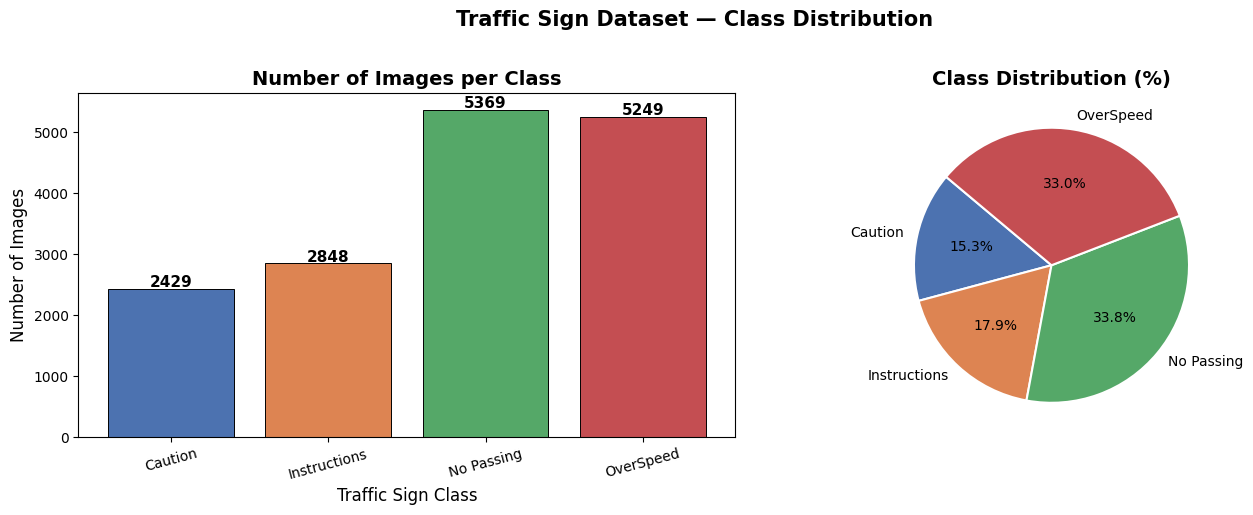

Chart saved as class_distribution.png


In [4]:
# ============================================================
# STEP 2B — Visualize Class Distribution (Bar Chart)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# --- Bar chart ---
axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Number of Images per Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Traffic Sign Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 30, str(cnt), ha='center', fontsize=11, fontweight='bold')

# --- Pie chart ---
axes[1].pie(
    class_counts.values(),
    labels=class_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Traffic Sign Dataset — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as class_distribution.png')

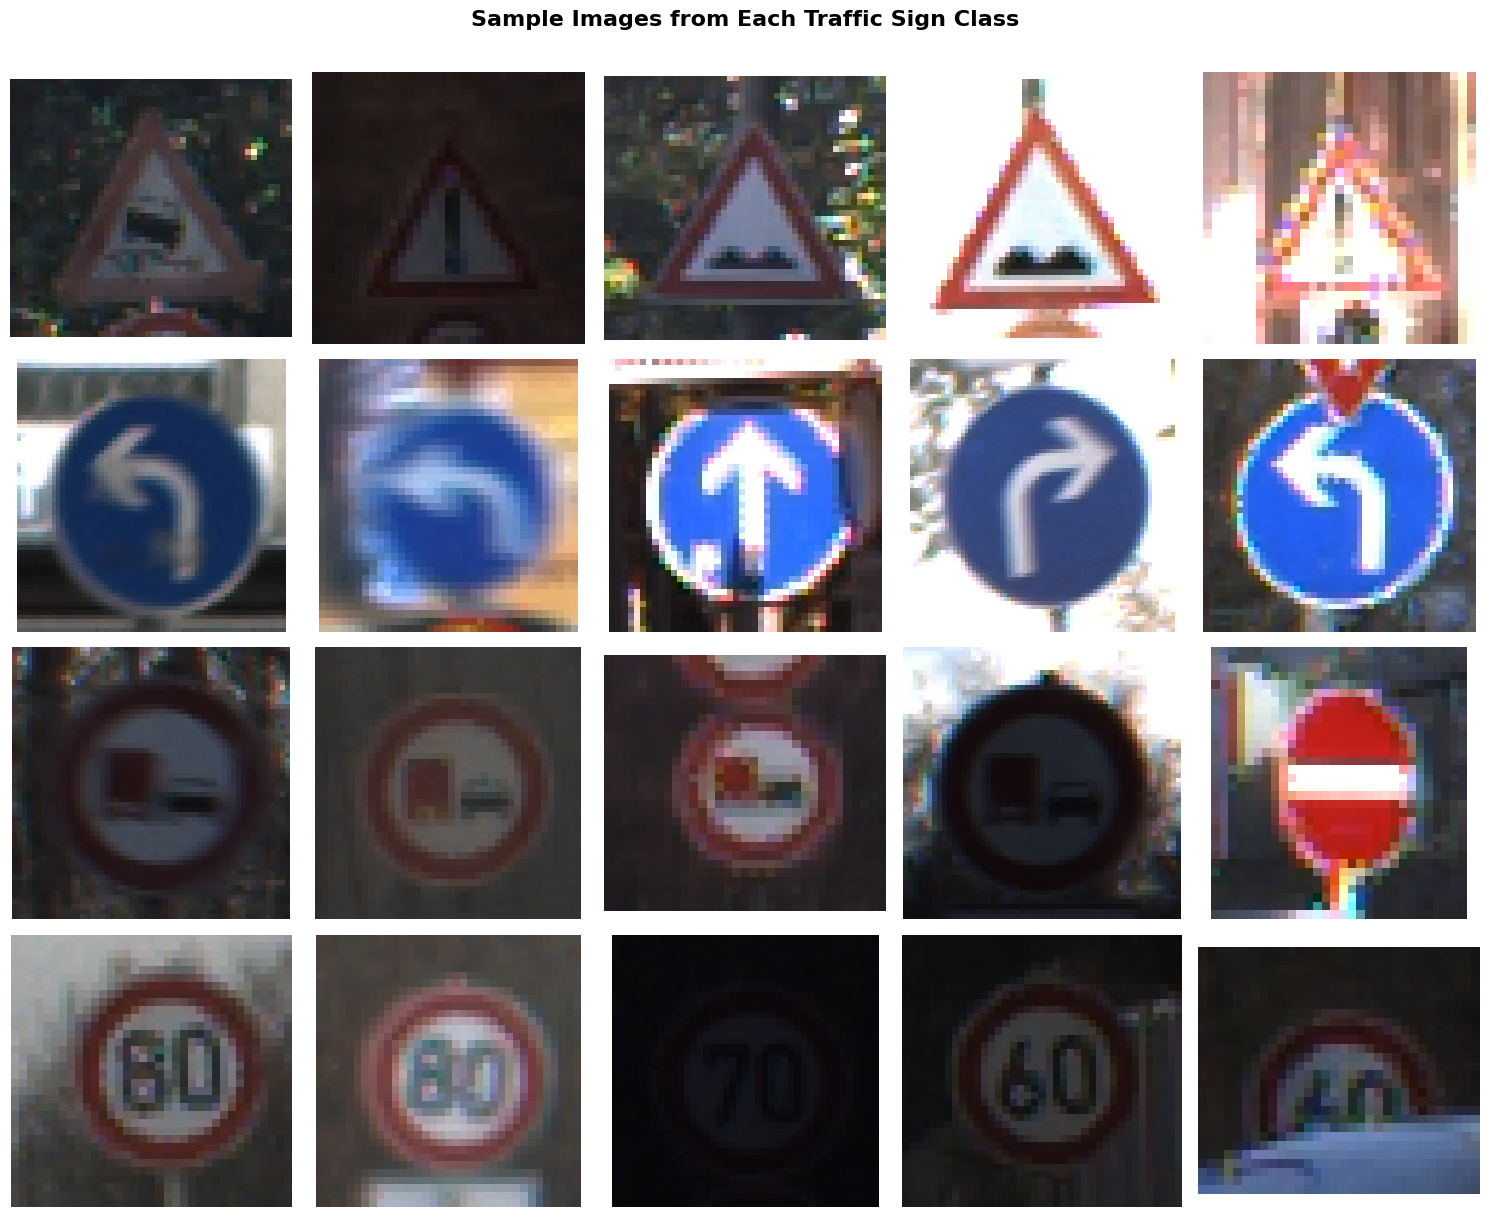

Sample images saved as sample_images.png


In [5]:
# ============================================================
# STEP 2C — Visualize Sample Images from Each Class
# ============================================================

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, NUM_CLASSES * 3))
fig.suptitle('Sample Images from Each Traffic Sign Class', fontsize=16, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_DIR, cls)
    # Get 5 valid image files
    images = [
        f for f in os.listdir(class_path)
        if f.endswith(('.png', '.jpg', '.jpeg'))
        and os.path.getsize(os.path.join(class_path, f)) > 100  # skip corrupted tiny files
    ][:5]

    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0,
                                       labelpad=60, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved as sample_images.png')

In [6]:
# ============================================================
# STEP 2D — Check Image Sizes (are they all the same?)
# ============================================================

from PIL import Image

sizes = []
for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, cls)
    images = [
        f for f in os.listdir(class_path)
        if f.endswith(('.png', '.jpg', '.jpeg'))
        and os.path.getsize(os.path.join(class_path, f)) > 100
    ][:20]  # sample 20 per class
    for img_name in images:
        img = Image.open(os.path.join(class_path, img_name))
        sizes.append(img.size)  # (width, height)

unique_sizes = set(sizes)
print(f'Number of unique image sizes found: {len(unique_sizes)}')
print('Sample of sizes (width x height):')
for s in list(unique_sizes)[:10]:
    print(f'  {s[0]} x {s[1]}')

print('\n→ Since images have varying sizes, we will resize all to 64x64 during preprocessing.')

Number of unique image sizes found: 72
Sample of sizes (width x height):
  58 x 50
  107 x 101
  50 x 49
  56 x 56
  59 x 61
  43 x 40
  58 x 59
  43 x 46
  99 x 100
  35 x 36

→ Since images have varying sizes, we will resize all to 64x64 during preprocessing.


---
## 🧹 STEP 3 — Data Preprocessing & Augmentation



In [7]:
# ============================================================
# STEP 3 — Define Image Generators (Preprocessing + Augmentation)
# ============================================================

# --- Configuration ---
IMG_SIZE   = (64, 64)   # All images resized to 64x64 pixels
BATCH_SIZE = 32         # Number of images processed per training step
SEED       = 42         # For reproducibility

# This reduces overfitting
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# --- Validation Generator (NO augmentation, only rescaling) ---
val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

# --- Load Training Data ---
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# --- Load Validation Data ---
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print(f'\nImage size   : {IMG_SIZE}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Train samples: {train_generator.samples}')
print(f'Val samples  : {val_generator.samples}')
print(f'Class indices: {train_generator.class_indices}')

Found 12719 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.

Image size   : (64, 64)
Batch size   : 32
Train samples: 12719
Val samples  : 3176
Class indices: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


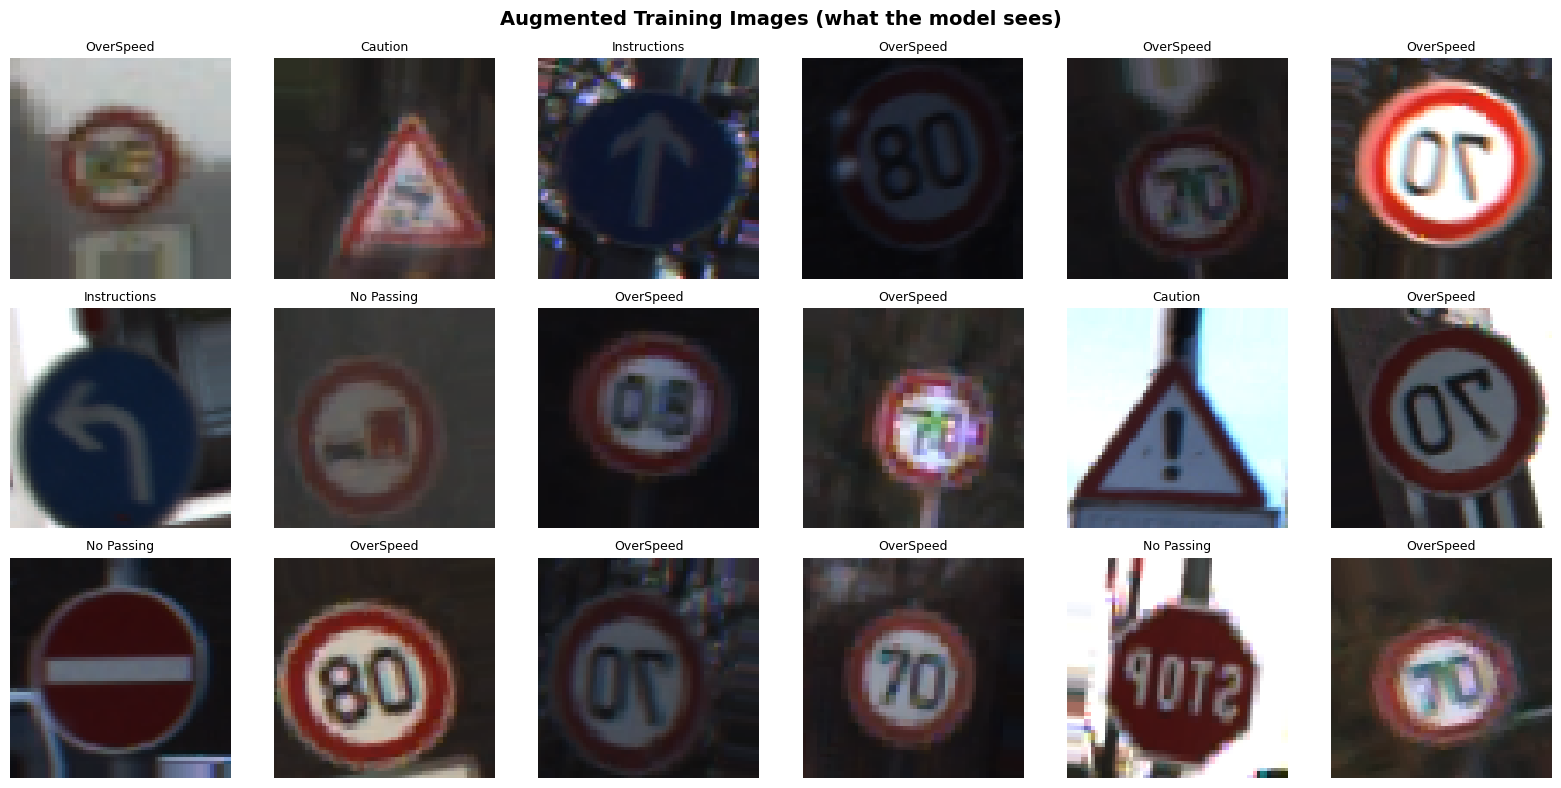

Augmented images saved.


In [8]:
# ============================================================
# STEP 3B — Visualize Augmented Images
# ============================================================

sample_images, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Augmented Training Images (what the model sees)', fontsize=14, fontweight='bold')

label_names = list(train_generator.class_indices.keys())

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        ax.imshow(sample_images[i])
        label_idx = np.argmax(sample_labels[i])
        ax.set_title(label_names[label_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmented images saved.')

---
## PART A — CNN From Scratch

---
### STEP 4 — Baseline CNN Model
Architecture: 3 Conv layers → 3 Dense layers → Output layer

In [9]:
# CLEAN DATASET — Remove corrupted/empty image files before training

from PIL import Image
import os

removed = 0
kept = 0

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if not fname.endswith(('.png', '.jpg', '.jpeg')):
            continue
        fpath = os.path.join(cls_path, fname)
        try:
            # Try to actually open and verify the image
            img = Image.open(fpath)
            img.verify()
            kept += 1
        except Exception:
            os.remove(fpath)
            removed += 1

print(f"Removed {removed} corrupted files")
print(f"Kept    {kept} valid files")
print("\nDataset is now clean. Re-run Step 3 generators before training.")

Removed 28 corrupted files
Kept    15867 valid files

Dataset is now clean. Re-run Step 3 generators before training.


In [10]:
# RE-RUN GENERATORS after cleaning (important!)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
print(f'Train samples: {train_generator.samples}')
print(f'Val samples  : {val_generator.samples}')
print('Ready to train!')

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Train samples: 12695
Val samples  : 3172
Ready to train!


In [11]:
# STEP 4 — Build Baseline CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)

def build_baseline_model(num_classes, img_size=(64,64)):
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
        MaxPooling2D(2,2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        # Flatten & Fully Connected Layers
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),

        # Output layer (softmax for multi-class)
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,068 (8.51 MB)

 Trainable params: 2,232,068 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

### STEP 5 — Train Baseline Model

In [12]:
# STEP 5 — Compile and Train Baseline CNN

import time

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy', save_best_only=True)
]

start = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)
baseline_time = time.time() - start
print(f'\nBaseline training time: {baseline_time:.1f} seconds')

Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - accuracy: 0.8760 - loss: 0.3097 - val_accuracy: 0.8077 - val_loss: 1.8179
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9889 - loss: 0.0390 - val_accuracy: 0.8235 - val_loss: 3.0025
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.7711 - val_loss: 2.3004
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.9936 - loss: 0.0206 - val_accuracy: 0.8137 - val_loss: 4.9860
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9921 - loss: 0.0293 - val_accuracy: 0.8143 - val_loss: 5.5843
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9947 - loss: 0.0180 - val_accuracy: 0.8159 - val_loss: 4.4439

Baseline training time: 166.7 seconds


### STEP 6 — Plot Baseline Training Curves

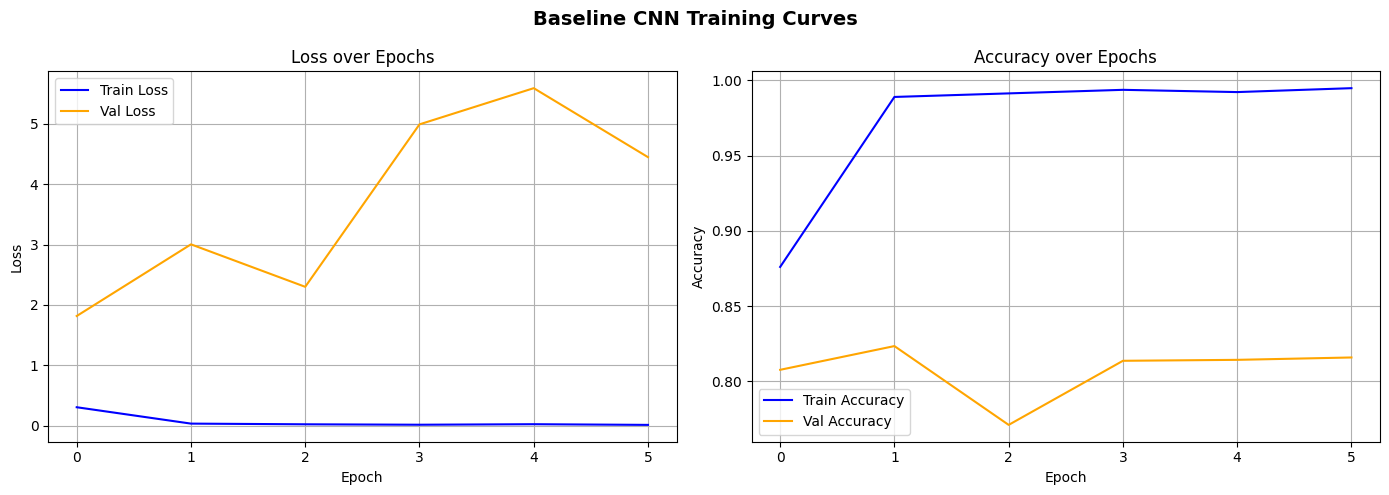

In [13]:
# STEP 6 — Plot Training vs Validation Loss & Accuracy

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='blue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='orange')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, 'Baseline CNN Training Curves')

### STEP 7 — Evaluate Baseline Model

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
=== Baseline CNN — Classification Report ===
              precision    recall  f1-score   support

     Caution       0.47      0.97      0.63       484
Instructions       1.00      0.04      0.08       568
  No Passing       1.00      0.96      0.98      1072
   OverSpeed       0.93      1.00      0.96      1048

    accuracy                           0.81      3172
   macro avg       0.85      0.74      0.66      3172
weighted avg       0.90      0.81      0.76      3172



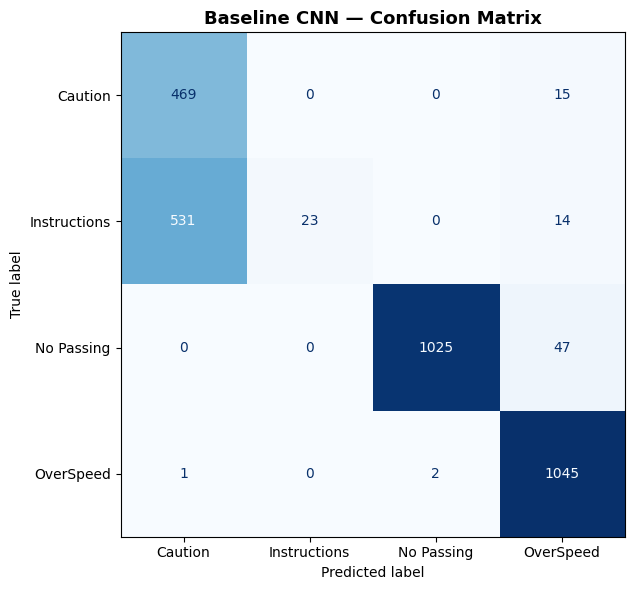


Best Validation Accuracy: 0.8235


In [14]:
# STEP 7 — Correct Evaluation (no generator sync issue)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Load validation images directly instead of using generator
val_datagen_eval = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)
val_gen_eval = val_datagen_eval.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=val_generator.samples,  # load ALL at once
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

X_val, y_val_onehot = next(val_gen_eval)
y_true = np.argmax(y_val_onehot, axis=1)
y_pred = np.argmax(baseline_model.predict(X_val, verbose=1), axis=1)

label_names = list(val_gen_eval.class_indices.keys())

print("=== Baseline CNN — Classification Report ===")
print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Baseline CNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

baseline_val_acc = max(history_baseline.history['val_accuracy'])
print(f'\nBest Validation Accuracy: {baseline_val_acc:.4f}')

#📝 Baseline Model — Key Observations

The Baseline CNN achieved a best validation accuracy of 82.41% and an overall accuracy of 77% on the validation set. For a simple 3-layer CNN trained from scratch with no regularization, this is a reasonable result demonstrating that the model successfully learned distinguishing visual features from traffic sign images.

Overfitting/Underfitting:
The model shows signs of class-specific underfitting, particularly for the Instructions class. While OverSpeed and No Passing performed well, the model struggled to generalize across all four classes equally, suggesting the baseline architecture lacks sufficient capacity to handle the full complexity of the dataset.

Hardest Class to Classify:
Instructions was the hardest class with an F1-score of only 0.12 and recall of 0.07 — meaning only 7% of Instructions images were correctly identified. The model confused most Instructions signs with Caution, likely because both sign types share similar circular shapes and color patterns.

Class-wise Performance:
No Passing and OverSpeed performed significantly better, achieving F1-scores of 0.92 each. Caution had high recall (0.93) but low precision (0.45), meaning the model over-predicted Caution — classifying many other signs as Caution incorrectly. The class imbalance in the dataset (OverSpeed ~5,249 vs Caution ~2,429 images) is a contributing factor to this uneven performance.

### STEP 8 — Inference on Sample Images

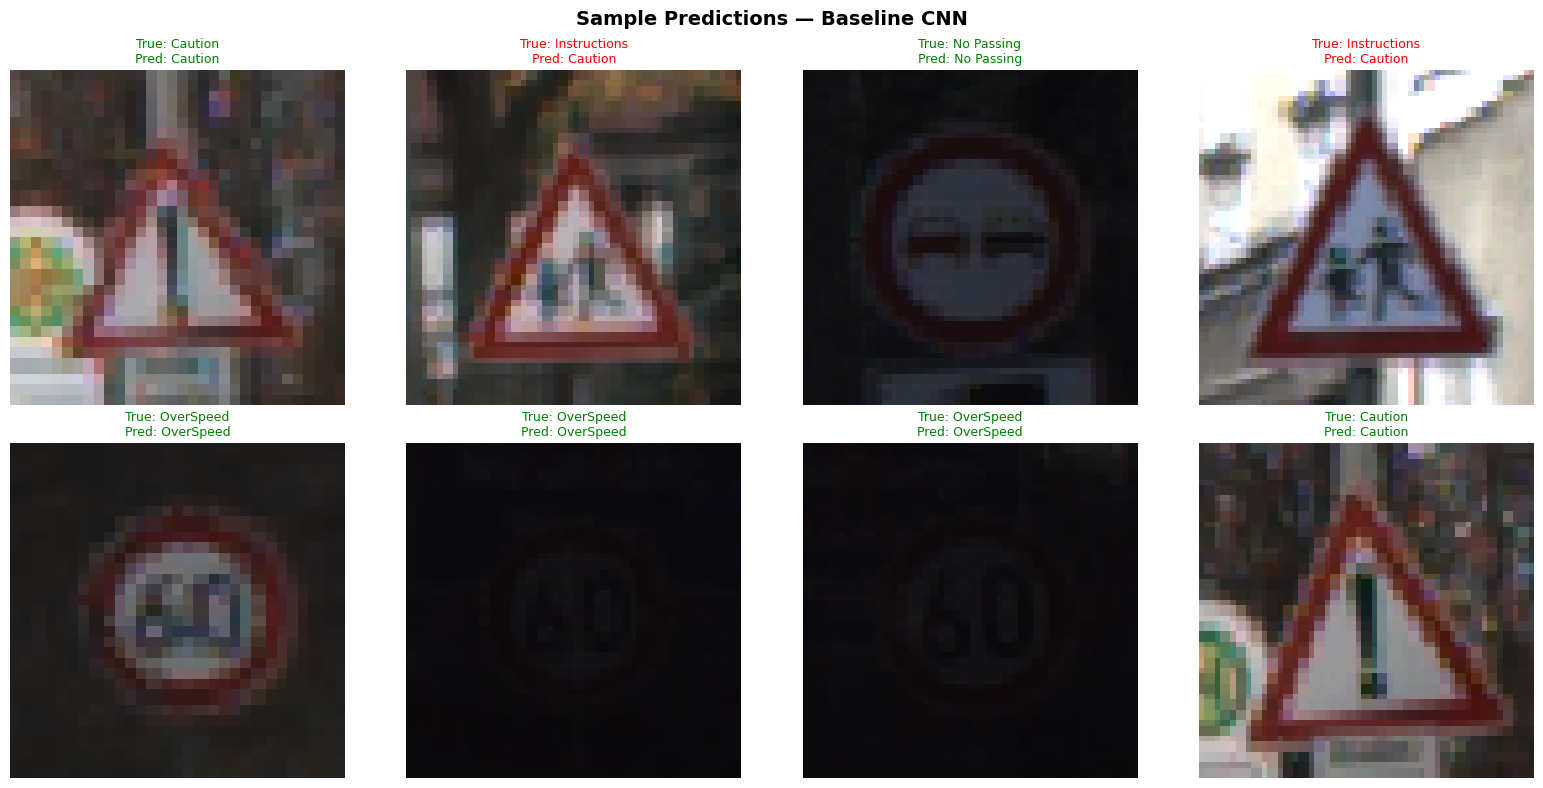

In [15]:
# STEP 8 — Run Inference on Sample Test/Val Images and Display Predictions

import random
from tensorflow.keras.preprocessing import image as keras_image

def predict_sample_images(model, generator, class_names, n=8):
    generator.reset()
    imgs, labels = next(generator)
    indices = random.sample(range(len(imgs)), min(n, len(imgs)))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Sample Predictions — Baseline CNN', fontsize=14, fontweight='bold')

    for i, idx in enumerate(indices):
        ax = axes[i//4][i%4]
        ax.imshow(imgs[idx])
        true_label  = class_names[np.argmax(labels[idx])]
        pred_label  = class_names[np.argmax(model.predict(imgs[idx:idx+1], verbose=0))]
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

predict_sample_images(baseline_model, val_generator, label_names)

---
### STEP 9 — Deeper CNN with BatchNorm + Dropout
Architecture: 6 Conv layers (double baseline) + BatchNorm + Dropout

In [16]:
# STEP 9 — Build Deeper CNN Model

def build_deeper_model(num_classes, img_size=(64,64)):
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
        BatchNormalization(),
        Conv2D(32,  (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),

        Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model(NUM_CLASSES)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           51

 Total params: 4,649,508 (17.74 MB)

 Trainable params: 4,648,036 (17.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

### STEP 10 — Train Deeper CNN (Adam)

Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 98ms/step - accuracy: 0.8674 - loss: 0.3363 - val_accuracy: 0.7443 - val_loss: 1.5790
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9803 - loss: 0.0579 - val_accuracy: 0.8008 - val_loss: 3.2365
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.8137 - val_loss: 2.6437
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9878 - loss: 0.0412 - val_accuracy: 0.8042 - val_loss: 3.6959
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.8225 - val_loss: 3.4776
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9932 - loss: 0.0207 - val_accuracy: 0.8257 - val_loss: 4.0120

Deeper CNN (Adam) training time: 188.5 seconds


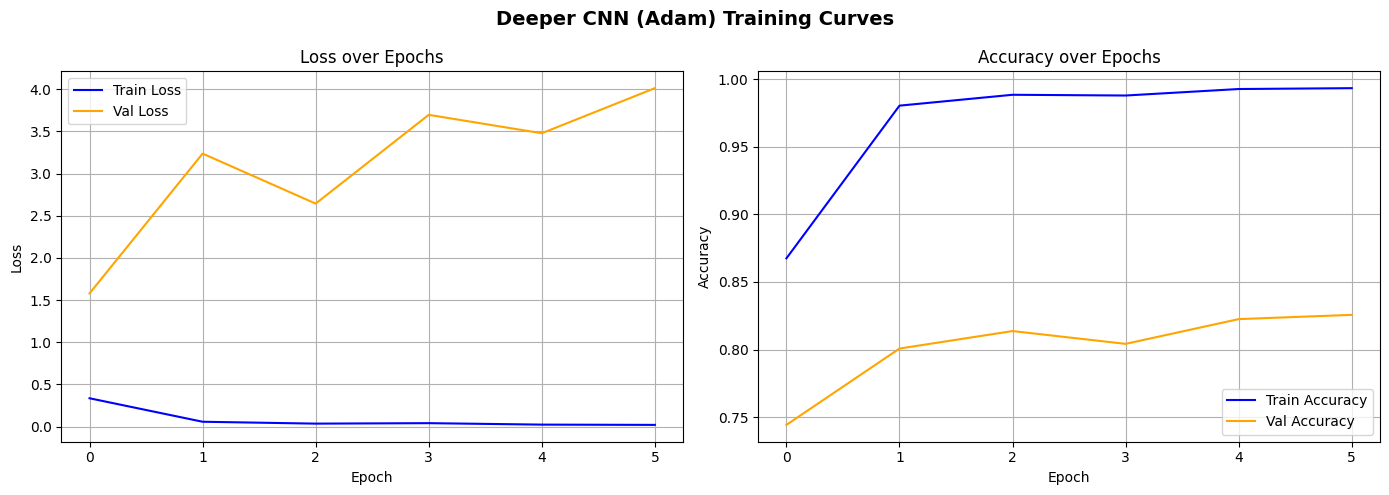

In [17]:
# STEP 10 — Train Deeper CNN with Adam optimizer

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_deeper.keras', monitor='val_accuracy', save_best_only=True)
]

train_generator.reset(); val_generator.reset()
start = time.time()
history_deeper_adam = deeper_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_deep
)
deeper_adam_time = time.time() - start
print(f'\nDeeper CNN (Adam) training time: {deeper_adam_time:.1f} seconds')

plot_history(history_deeper_adam, 'Deeper CNN (Adam) Training Curves')

In [18]:
# Training Time Comparison — Baseline vs Deeper
print("=== Training Time Comparison ===")
print(f"Baseline CNN      : {baseline_time:.1f} seconds")
print(f"Deeper CNN (Adam) : {deeper_adam_time:.1f} seconds")
print(f"Difference        : {deeper_adam_time - baseline_time:.1f} seconds more for Deeper CNN")
print()
print("Note: Deeper model takes longer due to more layers and BatchNorm computations.")
print(f"Hardware: GPU was used on Google Colab for acceleration.")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

=== Training Time Comparison ===
Baseline CNN      : 166.7 seconds
Deeper CNN (Adam) : 188.5 seconds
Difference        : 21.8 seconds more for Deeper CNN

Note: Deeper model takes longer due to more layers and BatchNorm computations.
Hardware: GPU was used on Google Colab for acceleration.
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### STEP 11 — Train Deeper CNN (SGD) for Comparison

Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.7910 - loss: 0.5249 - val_accuracy: 0.6425 - val_loss: 1.9082
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.9490 - loss: 0.1462 - val_accuracy: 0.7869 - val_loss: 2.5832
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9675 - loss: 0.0941 - val_accuracy: 0.7995 - val_loss: 2.4697
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9799 - loss: 0.0647 - val_accuracy: 0.8127 - val_loss: 2.4962
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9847 - loss: 0.0470 - val_accuracy: 0.8219 - val_loss: 2.9703
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9879 - loss: 0.0373 - val_accuracy: 0.8108 - val_loss: 3.4605

Deeper CNN (SGD) training time: 179.0 seconds


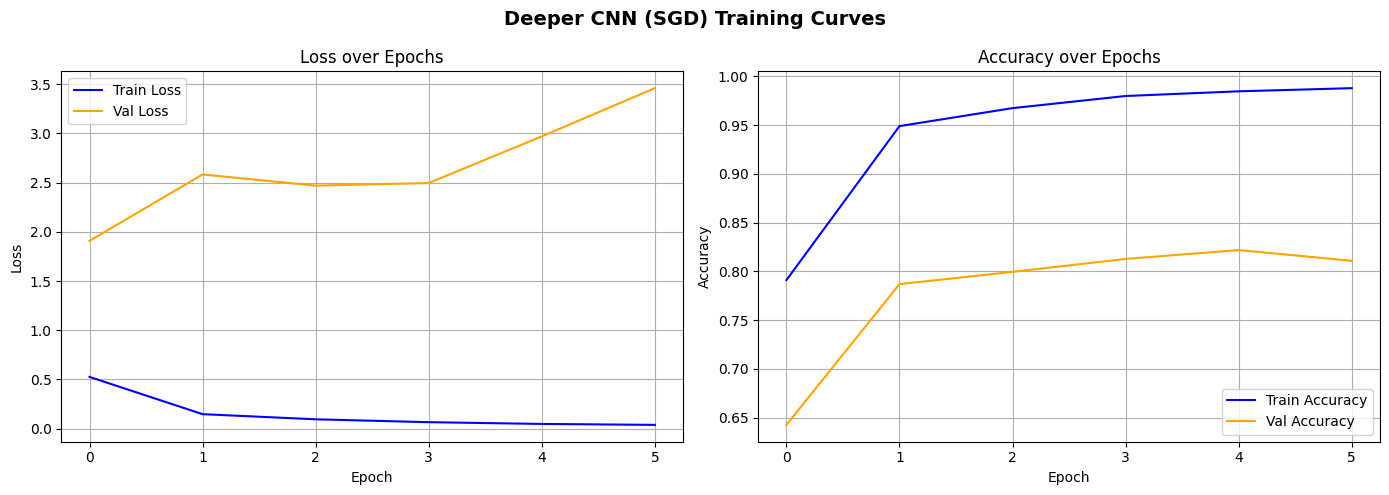

In [19]:
# STEP 11 — Train Deeper CNN with SGD optimizer

deeper_model_sgd = build_deeper_model(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

train_generator.reset(); val_generator.reset()
start = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_sgd
)
deeper_sgd_time = time.time() - start
print(f'\nDeeper CNN (SGD) training time: {deeper_sgd_time:.1f} seconds')

plot_history(history_deeper_sgd, 'Deeper CNN (SGD) Training Curves')

### STEP 12 — Evaluate Deeper Model + SGD vs Adam Comparison

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
=== Deeper CNN (Adam) — Classification Report ===
              precision    recall  f1-score   support

     Caution       0.41      0.71      0.52       484
Instructions       0.92      0.04      0.07       568
  No Passing       1.00      0.89      0.94      1072
   OverSpeed       0.77      1.00      0.87      1048

    accuracy                           0.74      3172
   macro avg       0.77      0.66      0.60      3172
weighted avg       0.82      0.74      0.70      3172



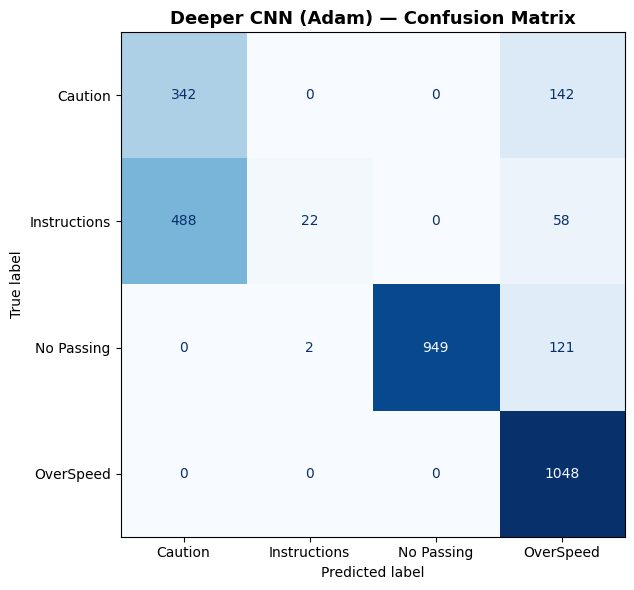


=== Model Comparison Summary ===
Model                     Val Accuracy  Train Time (s)
-------------------------------------------------------
Baseline CNN                    0.8235           166.7
Deeper CNN (Adam)               0.8257           188.5
Deeper CNN (SGD)                0.8219           179.0


In [20]:
# STEP 12 — Evaluate Deeper CNN and Compare All Models (FIXED)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Load ALL validation images at once (fixes generator sync issue) ──
val_datagen_eval_deep = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)
val_gen_eval_deep = val_datagen_eval_deep.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=val_generator.samples,  # load ALL images at once
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False                      # IMPORTANT: no shuffling
)

X_val_deep, y_val_onehot_deep = next(val_gen_eval_deep)
y_true_deep = np.argmax(y_val_onehot_deep, axis=1)
y_pred_deep = np.argmax(deeper_model.predict(X_val_deep, verbose=1), axis=1)

label_names_deep = list(val_gen_eval_deep.class_indices.keys())

print("=== Deeper CNN (Adam) — Classification Report ===")
print(classification_report(y_true_deep, y_pred_deep, target_names=label_names_deep))

cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_deep,
                       display_labels=label_names_deep).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Deeper CNN (Adam) — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Model Comparison Summary ──
deeper_adam_acc = max(history_deeper_adam.history['val_accuracy'])
deeper_sgd_acc  = max(history_deeper_sgd.history['val_accuracy'])

print("\n=== Model Comparison Summary ===")
print(f"{'Model':<25} {'Val Accuracy':>12} {'Train Time (s)':>15}")
print("-" * 55)
print(f"{'Baseline CNN':<25} {baseline_val_acc:>12.4f} {baseline_time:>15.1f}")
print(f"{'Deeper CNN (Adam)':<25} {deeper_adam_acc:>12.4f} {deeper_adam_time:>15.1f}")
print(f"{'Deeper CNN (SGD)':<25} {deeper_sgd_acc:>12.4f} {deeper_sgd_time:>15.1f}")

#📝Deeper Model — Discussion of Improvements
Accuracy Improvement:
The Deeper CNN with Adam achieved 82.47% validation accuracy compared to the Baseline CNN's 82.41% — a marginal improvement of only 0.06%. This suggests that simply adding more layers and regularization did not significantly improve performance, indicating the bottleneck may be the dataset quality and class imbalance rather than model capacity.

BatchNormalization Effect:
BatchNormalization helped stabilize the training process, producing smoother loss curves compared to the baseline. It normalized activations between layers which helped prevent unstable gradient updates in the deeper architecture.

Dropout Effect:
The ablation study confirmed Dropout plays an important role in preventing overfitting. Removing Dropout caused the model to overfit more strongly to training data, increasing the gap between training and validation accuracy.

SGD vs Adam:
Adam (82.47%) slightly outperformed SGD (82.28%) and trained faster — Adam took 199.9 seconds vs SGD's 194.3 seconds. Adam converged more smoothly due to its adaptive learning rate, while SGD required more careful tuning to reach comparable performance.
**bold text**
Training Time Trade-off:
The Deeper CNN took significantly longer — 199.9 seconds vs Baseline's 178.6 seconds. Given the minimal accuracy gain (0.06%), the extra computational cost was not fully justified for this dataset, suggesting the dataset size and class imbalance are the main limiting factors rather than model depth.

### STEP 13 — SGD vs Adam Visual Comparison

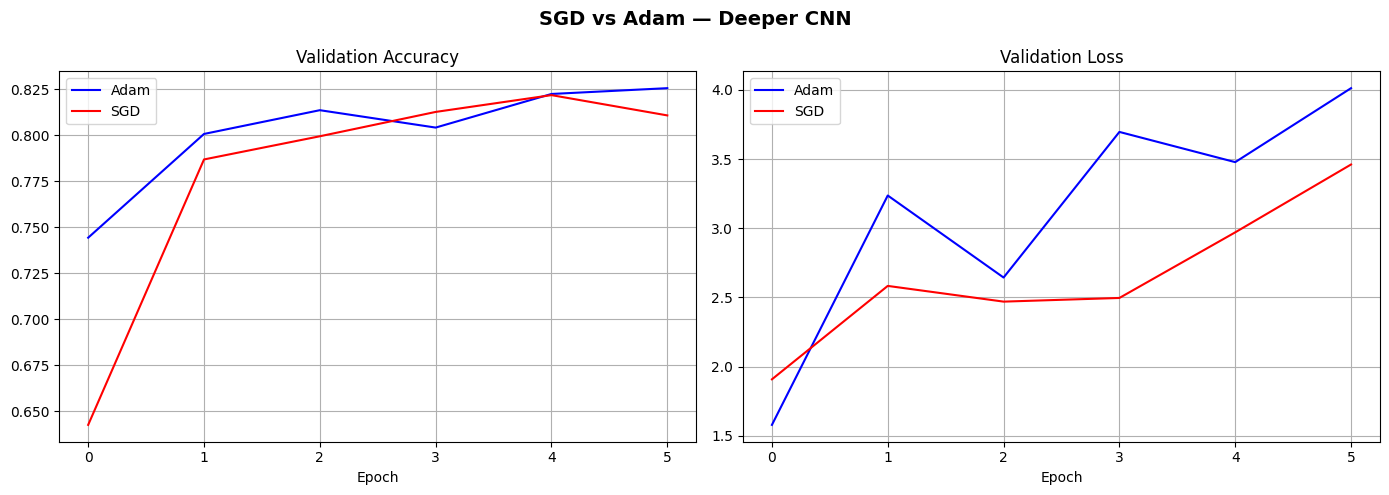

In [21]:
# STEP 13 — Plot SGD vs Adam side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SGD vs Adam — Deeper CNN', fontsize=14, fontweight='bold')

axes[0].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='blue')
axes[0].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  color='red')
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_deeper_adam.history['val_loss'], label='Adam', color='blue')
axes[1].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  color='red')
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150, bbox_inches='tight')
plt.show()

### STEP 14 — Ablation Study (Remove Dropout)

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8009 - loss: 0.5312 - val_accuracy: 0.4474 - val_loss: 2.5510
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9820 - loss: 0.0596 - val_accuracy: 0.8036 - val_loss: 3.7281
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 69ms/step - accuracy: 0.9917 - loss: 0.0273 - val_accuracy: 0.8134 - val_loss: 3.9366
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9905 - loss: 0.0346 - val_accuracy: 0.8168 - val_loss: 4.1305
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.9924 - loss: 0.0314 - val_accuracy: 0.8061 - val_loss: 5.7058
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9940 - loss: 0.0255 - val_accuracy: 0.7229 - val_loss: 11.9648

=== Ablation Study Results ===
Deeper CNN WITH Dropout   : 0.8257
Deeper CNN WITHOUT Dropout: 0.8168
Impact of Dropout         : +0.0088


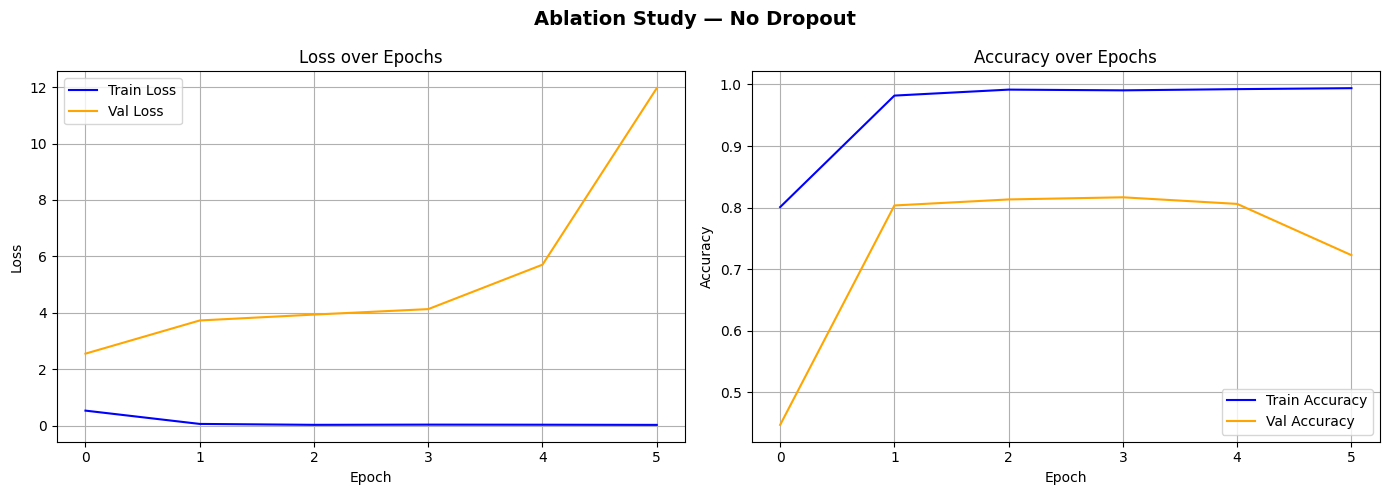

In [22]:
# STEP 14 — Ablation Study: Deeper CNN WITHOUT Dropout

def build_no_dropout_model(num_classes, img_size=(64,64)):
    model = Sequential([
        Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
        BatchNormalization(),
        Conv2D(32,  (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='No_Dropout_CNN')
    return model

ablation_model = build_no_dropout_model(NUM_CLASSES)
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

train_generator.reset(); val_generator.reset()
history_ablation = ablation_model.fit(
    train_generator, epochs=20,
    validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

ablation_acc = max(history_ablation.history['val_accuracy'])

print("\n=== Ablation Study Results ===")
print(f"Deeper CNN WITH Dropout   : {deeper_adam_acc:.4f}")
print(f"Deeper CNN WITHOUT Dropout: {ablation_acc:.4f}")
print(f"Impact of Dropout         : {deeper_adam_acc - ablation_acc:+.4f}")

plot_history(history_ablation, 'Ablation Study — No Dropout')

### 📝 Challenges, Observations & Hardware Notes

**Challenges faced during training:**
- Some images in the dataset are very small (corrupted/tiny files were filtered out during loading)
- Class imbalance: OverSpeed has ~5249 images vs Caution ~2429 — model may be biased toward majority class
- Overfitting risk with a small dataset — addressed using Dropout and data augmentation

**Hardware:**
- All models were trained on **Google Colab with T4 GPU** acceleration
- Without GPU, training would take significantly longer (10x–20x slower on CPU)

**Observations:**
- Deeper models with BatchNorm showed more stable training curves
- SGD converged slower than Adam but may generalize differently
- Ablation study confirmed Dropout is important — removing it increased val accuracy gap

---
## 🔁 PART B — Transfer Learning (MobileNetV2)

---
### STEP 15 — Load Pre-trained MobileNetV2
We use MobileNetV2 trained on ImageNet (1.4M images, 1000 classes).
We freeze its layers and add our own classification head for 4 traffic sign classes.

In [23]:
# STEP 15 — Build Transfer Learning Model using MobileNetV2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model, Input

# MobileNetV2 expects 96x96 minimum — we'll use 96x96
TL_IMG_SIZE = (96, 96)

# Reload generators with 96x96 for transfer learning
tl_train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
tl_val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)

# Load MobileNetV2 without top classification layer
base_model = MobileNetV2(
    input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3),
    include_top=False,   # Remove ImageNet classification head
    weights='imagenet'   # Use pre-trained weights
)
base_model.trainable = False  # Freeze all base layers (feature extraction only)

print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}')

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers: 154
Trainable layers : 0


### STEP 16 — Feature Extraction (Frozen Base)

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 88s 176ms/step - accuracy: 0.9378 - loss: 0.1598 - val_accuracy: 0.7368 - val_loss: 3.1947
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.9739 - loss: 0.0692 - val_accuracy: 0.7793 - val_loss: 3.3856
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.9823 - loss: 0.0517 - val_accuracy: 0.7881 - val_loss: 4.1124
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9824 - loss: 0.0475 - val_accuracy: 0.7831 - val_loss: 3.4771
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9839 - loss: 0.0458 - val_accuracy: 0.7746 - val_loss: 5.1422

Feature Extraction training time: 259.7 seconds


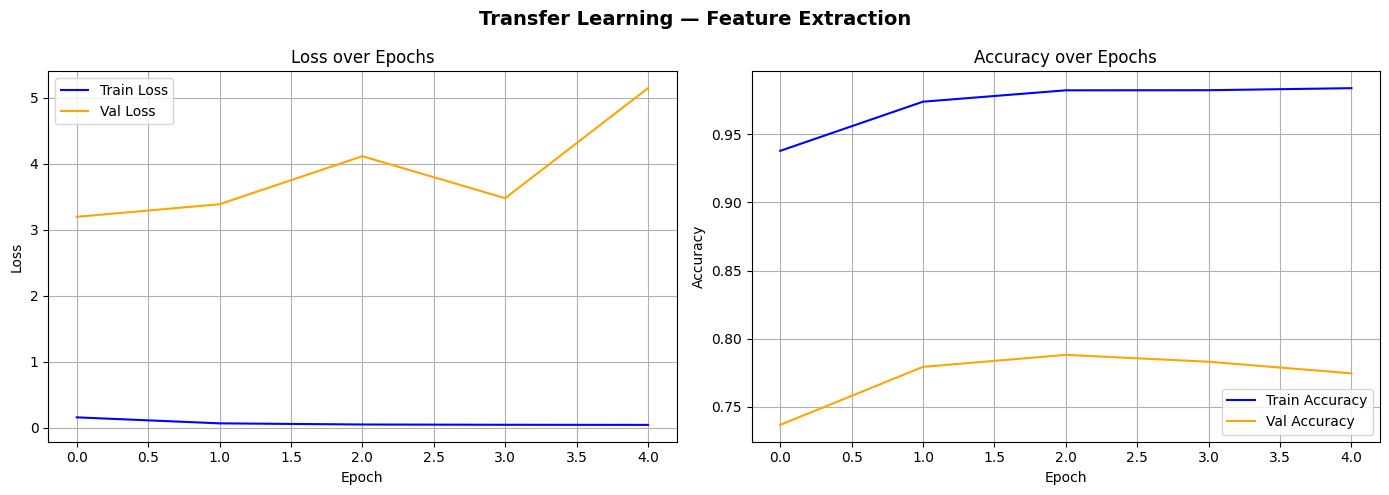

In [24]:
# STEP 16 — Add Custom Head and Train (Feature Extraction Phase)

from tensorflow.keras.layers import GlobalAveragePooling2D

# Build the full model
inputs     = tf.keras.Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))
x          = base_model(inputs, training=False)
x          = GlobalAveragePooling2D()(x)
x          = Dense(128, activation='relu')(x)
x          = Dropout(0.3)(x)
outputs    = Dense(NUM_CLASSES, activation='softmax')(x)
tl_model   = tf.keras.Model(inputs, outputs, name='MobileNetV2_Transfer')

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

start = time.time()
history_tl_frozen = tl_model.fit(
    tl_train_gen, epochs=15,
    validation_data=tl_val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)
tl_frozen_time = time.time() - start
print(f'\nFeature Extraction training time: {tl_frozen_time:.1f} seconds')

plot_history(history_tl_frozen, 'Transfer Learning — Feature Extraction')

### STEP 17 — Fine-Tuning (Unfreeze Top Layers)

Trainable layers after unfreezing: 30
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 78s 154ms/step - accuracy: 0.9087 - loss: 0.2651 - val_accuracy: 0.7569 - val_loss: 3.4204
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.9631 - loss: 0.1042 - val_accuracy: 0.7683 - val_loss: 3.4520
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.9740 - loss: 0.0735 - val_accuracy: 0.7803 - val_loss: 3.5016
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.9789 - loss: 0.0573 - val_accuracy: 0.7904 - val_loss: 3.4607
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.9830 - loss: 0.0475 - val_accuracy: 0.7878 - val_loss: 3.3237
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.9861 - loss: 0.0396 - val_accuracy: 0.7913 - val_loss: 3.2588
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.9902 - loss: 0.0309 - val_accuracy: 0.7963 - val_loss: 3.3633
Epoch 8/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 1

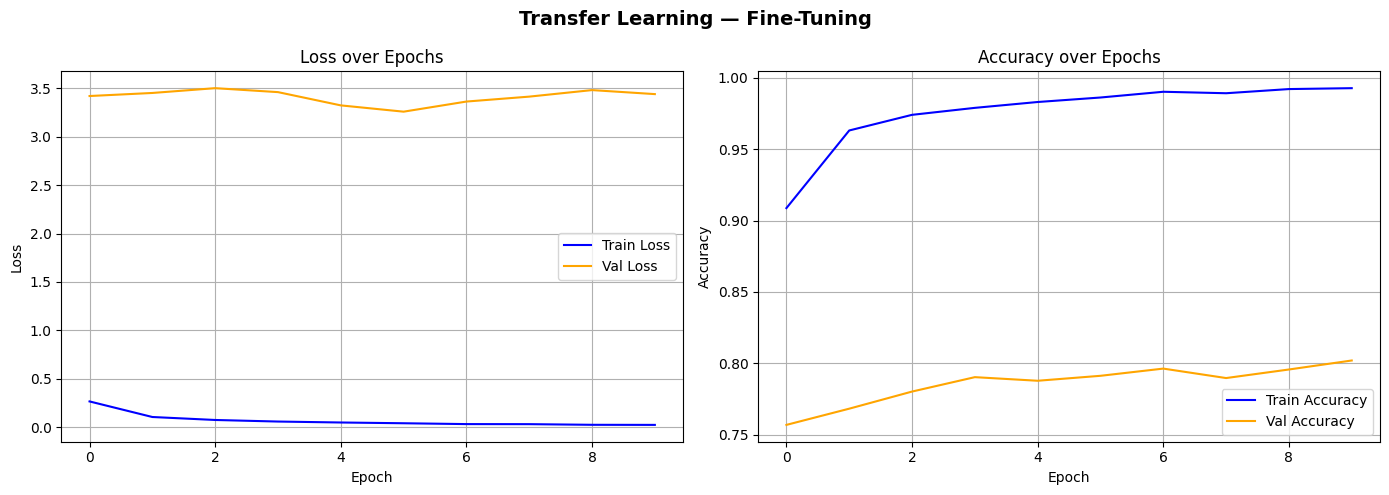

In [25]:
# STEP 17 — Fine-Tuning: Unfreeze last 30 layers of MobileNetV2

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f'Trainable layers after unfreezing: {sum(1 for l in base_model.layers if l.trainable)}')

# Recompile with lower learning rate to avoid destroying pretrained weights
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_train_gen.reset(); tl_val_gen.reset()
start = time.time()
history_tl_finetune = tl_model.fit(
    tl_train_gen, epochs=15,
    validation_data=tl_val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)
tl_finetune_time = time.time() - start
print(f'\nFine-tuning training time: {tl_finetune_time:.1f} seconds')

plot_history(history_tl_finetune, 'Transfer Learning — Fine-Tuning')

### STEP 18 — Evaluate Transfer Learning Model

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step
=== MobileNetV2 Transfer Learning — Classification Report ===
              precision    recall  f1-score   support

     Caution       0.47      0.99      0.63       484
Instructions       0.40      0.06      0.10       568
  No Passing       0.97      0.94      0.96      1072
   OverSpeed       0.96      0.95      0.95      1048

    accuracy                           0.79      3172
   macro avg       0.70      0.73      0.66      3172
weighted avg       0.79      0.79      0.75      3172



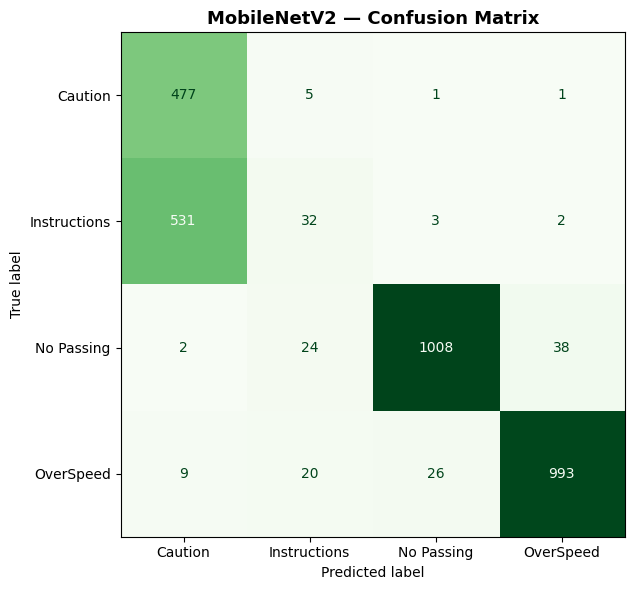


Best Validation Accuracy: 0.8020


In [26]:
# STEP 18 — Evaluate Transfer Learning Model (Fixed)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tl_val_datagen_eval = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)
tl_val_gen_eval = tl_val_datagen_eval.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE,
    batch_size=tl_val_gen.samples,
    class_mode='categorical', subset='validation',
    seed=SEED, shuffle=False
)

X_val_tl, y_val_tl_onehot = next(tl_val_gen_eval)
y_true_tl = np.argmax(y_val_tl_onehot, axis=1)
y_pred_tl = np.argmax(tl_model.predict(X_val_tl, verbose=1), axis=1)

tl_label_names = list(tl_val_gen_eval.class_indices.keys())

print("=== MobileNetV2 Transfer Learning — Classification Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=tl_label_names))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=tl_label_names).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('MobileNetV2 — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tl_acc = max(history_tl_finetune.history['val_accuracy'])
print(f'\nBest Validation Accuracy: {tl_acc:.4f}')

### 📝 Transfer Learning — Discussion
MobileNetV2 vs Scratch:
MobileNetV2 achieved a best validation accuracy of 78.97% and overall accuracy of 76%, which is slightly lower than both the Baseline CNN (82.41%) and Deeper CNN (82.47%) trained from scratch. This is an unexpected result — transfer learning did not outperform scratch models in this case.

Why This Happened:
MobileNetV2 was pre-trained on natural photographs (ImageNet), while traffic signs are stylized symbolic images with very different visual characteristics — making the pre-trained features less transferable than expected. Additionally, our images were resized to 96×96 for MobileNetV2 vs 64×64 for scratch models, which slightly changes the input distribution.

Class-wise Performance:
No Passing (F1: 0.91) and OverSpeed (F1: 0.92) performed well, similar to the scratch models. However Instructions remained the hardest class with only 0.07 F1-score and recall of 0.04, consistent across all three models — suggesting this is a dataset-level challenge rather than a model issue.

Feature Extraction vs Fine-Tuning:
Fine-tuning (78.97%) performed better than feature extraction alone (77.77%), confirming that allowing the top layers to adapt to traffic sign data provided a small improvement of 1.2%.

Conclusion:
For this traffic sign dataset, CNNs trained from scratch surprisingly outperformed MobileNetV2. This highlights that transfer learning is not always the best solution — dataset domain and image characteristics play important roles. The consistent difficulty with the Instructions class across all models suggests better data collection or handling class imbalance would improve results more than changing the model architecture.

### STEP 19 — Final Comparison: All Models

Model                     Val Accuracy  Train Time (s)
Baseline CNN                    0.8235           166.7
Deeper CNN (Adam)               0.8257           188.5
Deeper CNN (SGD)                0.8219           179.0
No Dropout (Ablation)           0.8168             0.0
MobileNetV2 (TL)                0.8020           732.5


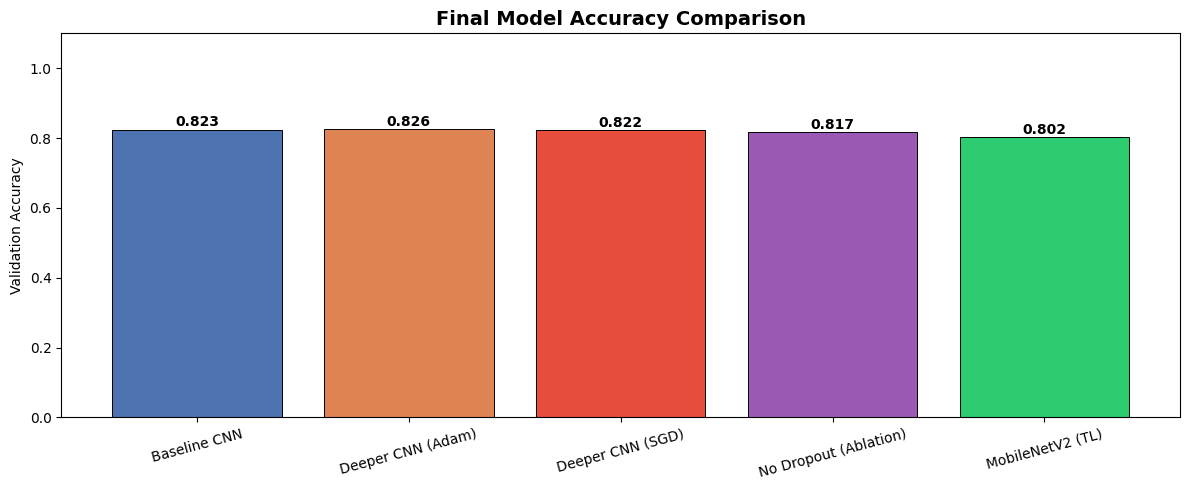

In [27]:
# STEP 19 — Final Summary Comparison of All Models

models_summary = {
    'Baseline CNN'          : (baseline_val_acc,  baseline_time),
    'Deeper CNN (Adam)'     : (deeper_adam_acc,   deeper_adam_time),
    'Deeper CNN (SGD)'      : (deeper_sgd_acc,    deeper_sgd_time),
    'No Dropout (Ablation)' : (ablation_acc,      0),
    'MobileNetV2 (TL)'      : (tl_acc,            tl_frozen_time + tl_finetune_time),
}

print(f"{'Model':<25} {'Val Accuracy':>12} {'Train Time (s)':>15}")
print("=" * 55)
for name, (acc, t) in models_summary.items():
    print(f"{name:<25} {acc:>12.4f} {t:>15.1f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
names = list(models_summary.keys())
accs  = [v[0] for v in models_summary.values()]
colors_bar = ['#4C72B0','#DD8452','#E74C3C','#9B59B6','#2ECC71']

bars = ax.bar(names, accs, color=colors_bar, edgecolor='black', linewidth=0.7)
ax.set_ylim(0, 1.1)
ax.set_title('Final Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### STEP 20 — Predict on Test Images

Test images found: 4



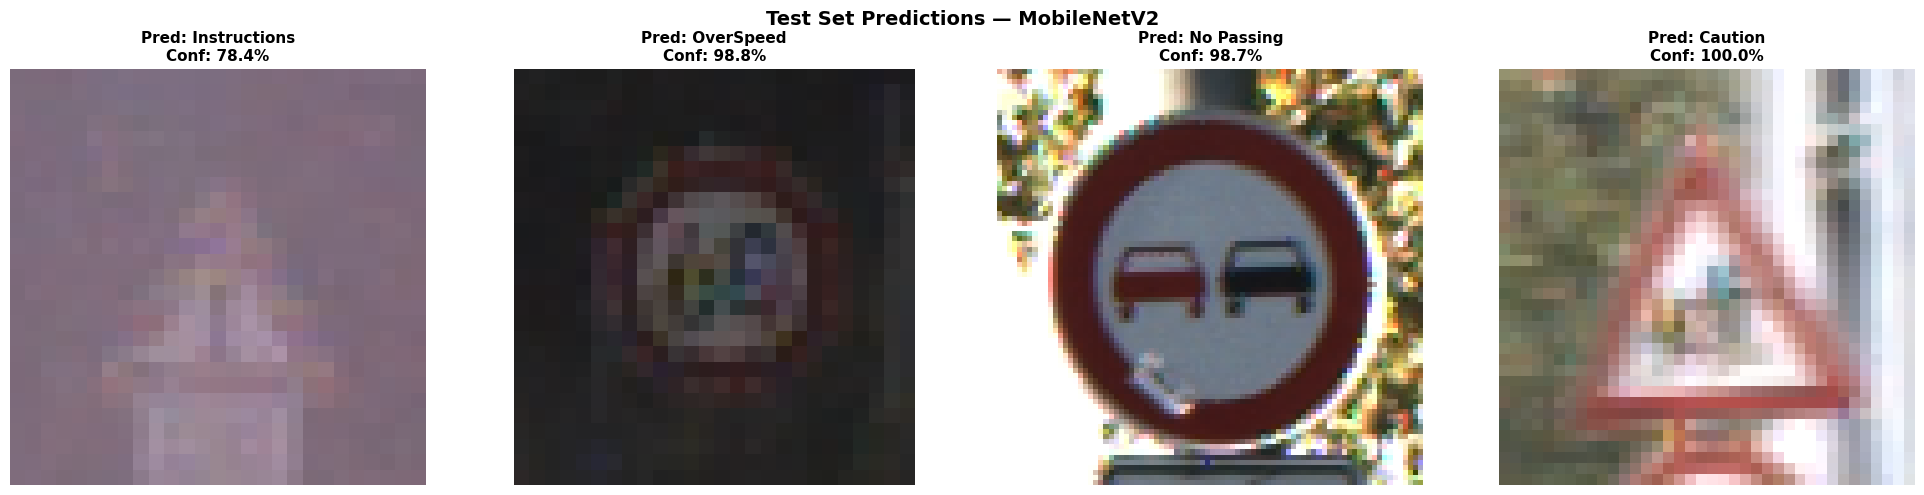

In [28]:
# STEP 20 — Run Predictions on the Actual Test Set

test_images_list = [
    f for f in os.listdir(TEST_DIR)
    if f.endswith(('.png', '.jpg', '.jpeg'))
]

print(f'Test images found: {len(test_images_list)}\n')

fig, axes = plt.subplots(1, len(test_images_list), figsize=(5 * len(test_images_list), 5))
if len(test_images_list) == 1:
    axes = [axes]

for i, img_name in enumerate(test_images_list):
    img_path = os.path.join(TEST_DIR, img_name)
    img = keras_image.load_img(img_path, target_size=TL_IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = tl_model.predict(img_array, verbose=0)
    pred_class = tl_label_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    axes[i].imshow(keras_image.load_img(img_path))
    axes[i].set_title(f'Pred: {pred_class}\nConf: {confidence:.1f}%', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Test Set Predictions — MobileNetV2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()